# Process Energy Demand Modelling — Debug Notebook

Step-by-step pipeline for interactive debugging.
Each section shows the exact data that goes into each algorithm (Petri net, ML) before running it.

**Import strategy:** imports from the individual `src/` modules, NOT from `modelling.py`  
(which is a script and runs the full pipeline on import).  
All utility functions live in `modelling_utils.py`.

## 0 · Setup

In [38]:
import os, sys, warnings
os.environ['TQDM_DISABLE'] = '1'
warnings.filterwarnings('ignore')

import logging
logging.getLogger('pm4py').setLevel(logging.ERROR)

# Make sure src/ is on the path
SRC_DIR = os.path.dirname(os.path.abspath('__file__'))
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pm4py
from pm4py.util import constants as pm4py_constants
pm4py_constants.SHOW_PROGRESS_BAR = False

import plotly.io as pio
pio.renderers.default = 'notebook'
pd.options.mode.chained_assignment = None

from IPython.display import display, Markdown
print('Setup complete.')

Setup complete.


In [39]:
# ── src module imports ────────────────────────────────────────────────────────
from modelling_utils import (
    load_process_datasets,
    _split_process_datasets,
    comprehensive_simulation_evaluation,
    plot_simulation_comparison,
    visualize_heuristic_nets,
    _plot_short_heatmap,
    MODES_TO_COMPARE,
)
from sim_extractor import (
    extract_process,
    fit_best_distribution,
    extract_energy_modifiers,
    extract_energy_direct_models,
)
from sim_modeller import SimModeller
from simulation import ProcessSimulation
from energy_profile_extractor import EnergyProfileExtractor

print("All src modules imported.")


All src modules imported.


## 1 · Configuration

Edit these variables to control which process / mode / algorithm is run.

In [40]:
# ── Experiment & data ─────────────────────────────────────────────────────────
EXPERIMENT          = '1'               # gold experiment folder
PROCESS_NAME        = 'process_1'       # which process to debug
TRAIN_RATIO         = 0.80
TEMPORAL_RESOLUTION = '15min'           # 'original' | '5min' | '15min'

# ── Simulation mode ───────────────────────────────────────────────────────────
# One of: 'statistical', 'petri_net_alpha', 'petri_net_heuristic',
#         'petri_net_inductive', 'petri_net_combined', 'petri_net_ilp',
#         'petri_net_energy_aware', 'petri_net_energy_direct', ...
SIMULATION_MODE     = 'petri_net_inductive'

# ── ML options ────────────────────────────────────────────────────────────────
ML_MODEL_TYPES      = ['xgboost']       # ['xgboost', 'linear', 'lasso', 'mlp']
OPTIMIZE_HYPERPARAMS = False

# ── Energy profile ────────────────────────────────────────────────────────────
# Sensor column in the expanded DataFrame to model (None = skip energy section)
ENERGY_SENSOR_COL   = None              # e.g. 'autoclave_steam_demand_kW_energy'

# ── Number of cases to simulate ───────────────────────────────────────────────
N_CASES_TO_SIMULATE = None              # None = match test set size

print(f'Process: {PROCESS_NAME}  |  Mode: {SIMULATION_MODE}  |  Experiment: {EXPERIMENT}')

Process: process_1  |  Mode: petri_net_inductive  |  Experiment: 1


## 2 · Load Data

In [41]:
process_datasets = load_process_datasets(EXPERIMENT)
print('\nAvailable processes:', list(process_datasets.keys()))

Loaded process_1: event_log=7000 rows, expanded=35065 rows
Loaded process_2: event_log=2587 rows, expanded=736986 rows
Loaded process_3: event_log=256 rows, expanded=145256 rows
Loaded process_4: event_log=1935 rows, expanded=30042 rows

Available processes: ['process_1', 'process_2', 'process_3', 'process_4']


In [42]:
# Optionally aggregate expanded to coarser temporal resolution
import re
if TEMPORAL_RESOLUTION != 'original':
    from modelling_utils import _aggregate_expanded
    for _pname, _pdata in process_datasets.items():
        if _pdata.get('expanded') is not None:
            _pdata['expanded'] = _aggregate_expanded(_pdata['expanded'], TEMPORAL_RESOLUTION)
    print(f'Aggregated expanded to {TEMPORAL_RESOLUTION}')

# Add temporal features to expanded
for _pname, _pdata in process_datasets.items():
    _exp = _pdata.get('expanded')
    if _exp is not None and 'datetime_energy' in _exp.columns:
        _dt = pd.to_datetime(_exp['datetime_energy'])
        _exp['ef_hour_of_day'] = _dt.dt.hour.astype(float)
        _exp['ef_day_of_week'] = _dt.dt.dayofweek.astype(float)

# Train / test split
train_datasets, test_datasets = _split_process_datasets(process_datasets, TRAIN_RATIO)

pdata_train = train_datasets[PROCESS_NAME]
pdata_test  = test_datasets[PROCESS_NAME]
print(f'\nProcess "{PROCESS_NAME}" ready.')

Aggregated expanded to 15min
  process_1: 400 train / 100 test cases  |  event_log 5600/1400  |  production_plan 400/100  |  expanded 400/219
  process_2: 39 train / 10 test cases  |  event_log 2012/575  |  production_plan 39/10  |  expanded 1556/493
  process_3: 24 train / 6 test cases  |  event_log 214/42  |  production_plan 23/6  |  expanded 1121/493
  process_4: 42 train / 11 test cases  |  event_log 1272/457  |  production_plan 39/10  |  expanded 989/443

Process "process_1" ready.


## 3 · Inspect Event Log (Petri Net Input)

This is exactly what goes into `extract_process()` / `pm4py.discover_*` calls.

In [43]:
el_train = pdata_train['event_log']
el_test  = pdata_test['event_log']

print(f'Train event log: {el_train.shape}  |  Test event log: {el_test.shape}')
display(el_train.dtypes.to_frame('dtype'))
display(el_train.head(5))

Train event log: (5600, 9)  |  Test event log: (1400, 9)


,dtype
case_id,object
activity,object
timestamp_start,datetime64[ns]
timestamp_end,datetime64[ns]
higher_level_activity,object
station,object
object_type,object
object,object
object_attributes,object


,case_id,activity,timestamp_start,timestamp_end,higher_level_activity,station,object_type,object,object_attributes
0,batch_001,water_supply_prepare,2024-01-15 00:00:00.000000,2024-01-15 00:00:05.559925,sterilization_process,Water_supply,sterilization_line,water_supply,"{'recipe': 'standard', 'volume_L': 463.3}"
1,batch_001,water_supply_working,2024-01-15 00:00:06.559925,2024-01-15 00:01:13.906558,sterilization_process,Water_supply,sterilization_line,water_supply,"{'recipe': 'standard', 'volume_L': 463.3}"
2,batch_001,destillation_heat,2024-01-15 00:01:14.906558,2024-01-15 00:01:47.615250,sterilization_process,Destillation,sterilization_line,destillation,"{'recipe': 'standard', 'volume_L': 463.3}"
3,batch_001,bottling_prepare,2024-01-15 00:01:48.615250,2024-01-15 00:01:54.175175,sterilization_process,Bottling,sterilization_line,bottling,"{'recipe': 'standard', 'volume_L': 463.3}"
4,batch_001,bottling_working,2024-01-15 00:01:55.175175,2024-01-15 00:02:32.664783,sterilization_process,Bottling,sterilization_line,bottling,"{'recipe': 'standard', 'volume_L': 463.3}"


Activity counts (train):


,count
activity,
water_supply_prepare,400
water_supply_working,400
destillation_heat,400
bottling_prepare,400
bottling_working,400
bottling_cool,400
packaging_working,400
warehousing_prepare,400
warehousing_working,400


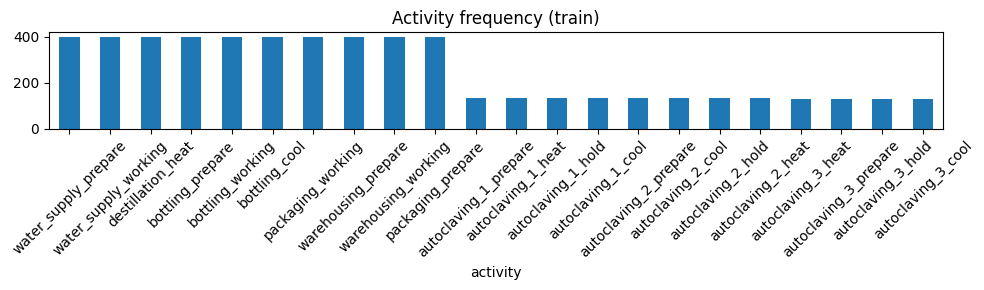

In [44]:
# Activity distribution
act_counts = el_train['activity'].value_counts()
print('Activity counts (train):')
display(act_counts.to_frame('count'))

act_counts.plot(kind='bar', figsize=(10, 3), title='Activity frequency (train)', rot=45)
plt.tight_layout(); plt.show()

In [45]:
# Case-level statistics
case_stats = el_train.groupby('case_id').agg(
    n_events=('activity', 'count'),
    duration_h=('timestamp_start', lambda x: (
        el_train.loc[x.index, 'timestamp_end'].max() - x.min()
    ).total_seconds() / 3600),
    start=('timestamp_start', 'min'),
    activities=('activity', lambda x: list(x.unique()))
)
print(f'Cases in train: {len(case_stats)}')
display(case_stats.describe())

Cases in train: 400


,n_events,duration_h,start
count,400.0,400.000000,400
mean,14.0,13.408858,2024-01-17 01:52:30.000000256
min,14.0,1.406833,2024-01-15 00:00:00
25%,14.0,6.974614,2024-01-16 00:56:15
50%,14.0,13.652561,2024-01-17 01:52:30
75%,14.0,19.826725,2024-01-18 02:48:45
max,14.0,25.617708,2024-01-19 03:45:00
std,0.0,7.197599,NaN


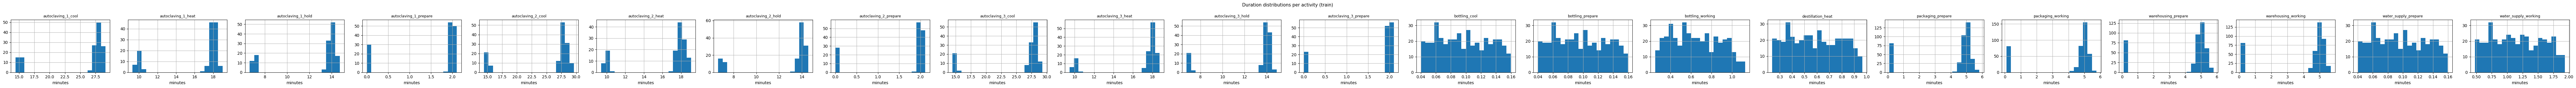

In [46]:
# Per-activity duration distributions
if 'timestamp_end' in el_train.columns:
    el_train['duration_min'] = (el_train['timestamp_end'] - el_train['timestamp_start']).dt.total_seconds() / 60
    n_acts = el_train['activity'].nunique()
    fig, axes = plt.subplots(1, n_acts, figsize=(4 * n_acts, 3), sharey=False)
    if n_acts == 1: axes = [axes]
    for ax, (act, grp) in zip(axes, el_train.groupby('activity')):
        grp['duration_min'].hist(ax=ax, bins=20)
        ax.set_title(act, fontsize=9)
        ax.set_xlabel('minutes')
    plt.suptitle('Duration distributions per activity (train)', fontsize=11)
    plt.tight_layout(); plt.show()

In [47]:
# Directly-follows graph
el_fmt = pm4py.format_dataframe(el_train.dropna(subset=['case_id', 'activity', 'timestamp_start']),
                                 case_id='case_id', activity_key='activity',
                                 timestamp_key='timestamp_start')
dfg, start_acts, end_acts = pm4py.discover_dfg(el_fmt)
print('DFG edges (top 15 by frequency):')
display(pd.Series(dfg).sort_values(ascending=False).head(15).to_frame('freq'))
print('Start activities:', start_acts)
print('End activities:  ', end_acts)

DFG edges (top 15 by frequency):


,,freq
bottling_working,bottling_cool,400
destillation_heat,bottling_prepare,400
packaging_prepare,packaging_working,400
packaging_working,warehousing_prepare,400
warehousing_prepare,warehousing_working,400
water_supply_prepare,water_supply_working,400
water_supply_working,destillation_heat,400
bottling_prepare,bottling_working,400
bottling_cool,autoclaving_1_prepare,135
autoclaving_1_cool,packaging_prepare,135


Start activities: {'water_supply_prepare': 400}
End activities:   {'warehousing_working': 400}


## 4 · Inspect Energy / Expanded Data (ML Input)

This is what `extract_energy_modifiers` / `EnergyProfileExtractor` use as input.

In [48]:
exp_train = pdata_train['expanded']
if exp_train is not None:
    print(f'Expanded train shape: {exp_train.shape}')
    display(exp_train.dtypes.to_frame('dtype'))
    display(exp_train.head(5))
else:
    print('No expanded data for this process.')

Expanded train shape: (400, 20)


,dtype
datetime_energy,datetime64[ns]
ef_temperature_2m_energy,float64
ef_relative_humidity_2m_energy,float64
destillation_steam_demand_kW_energy,float64
autoclave_steam_demand_kW_energy,float64
autoclave_cooling_water_demand_kW_energy,float64
bottling_power_kW_energy,float64
packaging_power_kW_energy,float64
water_supply_power_kW_energy,float64
timestamp_start_log,datetime64[ns]


,datetime_energy,ef_temperature_2m_energy,ef_relative_humidity_2m_energy,destillation_steam_demand_kW_energy,autoclave_steam_demand_kW_energy,autoclave_cooling_water_demand_kW_energy,bottling_power_kW_energy,packaging_power_kW_energy,water_supply_power_kW_energy,timestamp_start_log,timestamp_end_log,activity_log,higher_level_activity_log,station_log,object_type_log,object_log,case_id_log,object_attributes_log,ef_hour_of_day,ef_day_of_week
0,2024-01-15 00:00:00,2.867470,83.200048,0.000000,69.030865,0.000000,2.220631,0.000000,0.472935,2024-01-15 00:00:00,2024-01-15 00:00:05.559925,water_supply_prepare,sterilization_process,Water_supply,sterilization_line,water_supply,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}",0.0,0.0
1,2024-01-15 00:15:00,2.987519,84.837654,0.109548,133.819216,0.000000,1.309669,0.000000,0.242756,2024-01-15 00:15:00,2024-01-15 00:15:02.859484,water_supply_prepare,sterilization_process,Water_supply,sterilization_line,water_supply,batch_002,"{'recipe': 'standard', 'volume_L': 238.3}",0.0,0.0
2,2024-01-15 00:30:00,3.587410,85.100940,0.008641,116.423545,9.333473,0.970301,0.000000,0.190925,2024-01-15 00:30:00,2024-01-15 00:30:05.067310,water_supply_prepare,sterilization_process,Water_supply,sterilization_line,water_supply,batch_003,"{'recipe': 'standard', 'volume_L': 422.3}",0.0,0.0
3,2024-01-15 00:45:00,3.233282,84.509142,0.018648,82.003103,28.817645,0.859959,0.000000,0.169484,2024-01-15 00:45:00,2024-01-15 00:45:02.453008,water_supply_prepare,sterilization_process,Water_supply,sterilization_line,water_supply,batch_004,"{'recipe': 'standard', 'volume_L': 204.4}",0.0,0.0
4,2024-01-15 01:00:00,4.535511,83.338167,0.000000,31.904764,25.438899,0.706320,2.323784,0.138500,2024-01-15 01:00:00,2024-01-15 01:00:04.588441,water_supply_prepare,sterilization_process,Water_supply,sterilization_line,water_supply,batch_005,"{'recipe': 'standard', 'volume_L': 382.4}",1.0,0.0


In [49]:
# Identify energy / sensor columns
if exp_train is not None:
    numeric_cols = exp_train.select_dtypes(include='number').columns.tolist()
    energy_cols  = [c for c in numeric_cols if 'energy' in c.lower() or 'kW' in c or 'power' in c.lower()]
    print(f'Numeric columns ({len(numeric_cols)}):', numeric_cols[:20], '...' if len(numeric_cols) > 20 else '')
    print(f'\nEnergy/power columns ({len(energy_cols)}):', energy_cols)

Numeric columns (10): ['ef_temperature_2m_energy', 'ef_relative_humidity_2m_energy', 'destillation_steam_demand_kW_energy', 'autoclave_steam_demand_kW_energy', 'autoclave_cooling_water_demand_kW_energy', 'bottling_power_kW_energy', 'packaging_power_kW_energy', 'water_supply_power_kW_energy', 'ef_hour_of_day', 'ef_day_of_week'] 

Energy/power columns (8): ['ef_temperature_2m_energy', 'ef_relative_humidity_2m_energy', 'destillation_steam_demand_kW_energy', 'autoclave_steam_demand_kW_energy', 'autoclave_cooling_water_demand_kW_energy', 'bottling_power_kW_energy', 'packaging_power_kW_energy', 'water_supply_power_kW_energy']


In [50]:
# Plot a sensor if configured
if exp_train is not None and ENERGY_SENSOR_COL and ENERGY_SENSOR_COL in exp_train.columns:
    _dt = 'datetime_energy' if 'datetime_energy' in exp_train.columns else exp_train.columns[0]
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(pd.to_datetime(exp_train[_dt]), exp_train[ENERGY_SENSOR_COL], lw=0.6, alpha=0.8)
    ax.set_title(f'{ENERGY_SENSOR_COL} — train set'); ax.set_ylabel('value')
    plt.tight_layout(); plt.show()
elif exp_train is not None and energy_cols:
    print(f'Tip: set ENERGY_SENSOR_COL to one of {energy_cols[:5]} to plot the time series.')

Tip: set ENERGY_SENSOR_COL to one of ['ef_temperature_2m_energy', 'ef_relative_humidity_2m_energy', 'destillation_steam_demand_kW_energy', 'autoclave_steam_demand_kW_energy', 'autoclave_cooling_water_demand_kW_energy'] to plot the time series.


In [51]:
# Show columns available as energy features in SimModeller
if exp_train is not None:
    ef_cols = [c for c in exp_train.columns if c.startswith('ef_')]
    print('Energy feature columns (ef_*) that SimModeller will use:')
    display(exp_train[ef_cols].describe() if ef_cols else pd.DataFrame({'note': ['no ef_ columns found']}))

Energy feature columns (ef_*) that SimModeller will use:


,ef_temperature_2m_energy,ef_relative_humidity_2m_energy,ef_hour_of_day,ef_day_of_week
count,400.000000,400.000000,400.000000,400.000000
mean,3.540146,84.172695,11.100000,1.600000
std,3.506287,2.887173,7.072131,1.201503
min,-2.017185,78.629681,0.000000,0.000000
25%,0.016576,81.630186,5.000000,1.000000
50%,3.625342,84.231596,11.000000,2.000000
75%,6.982625,86.841475,17.000000,3.000000
max,8.925775,89.752123,23.000000,4.000000


## 5 · Process Discovery (Petri Net Mining)

In [52]:
# Choose mining algorithm for inspection
# (extract_process auto-selects best for energy-aware modes)
MINING_ALGORITHM = "heuristic"   # "alpha" | "heuristic" | "inductive" | "ilp"

print(f"Running extract_process() with {MINING_ALGORITHM} miner ...")
stats_df, raw_df, process_models = extract_process(
    el_train,
    mining_algorithm=MINING_ALGORITHM,
)
print(f"stats_df: {stats_df.shape}  |  raw_df: {raw_df.shape}")
print(f"Extracted {len(process_models)} station model(s):")
for key, entry in process_models.items():
    net = entry["net"]
    print(f"  {key}  |  places={len(net.places)}  transitions={len(net.transitions)}  arcs={len(net.arcs)}")


Running extract_process() with heuristic miner ...

Processing: sterilization_process (8 objects, one whole-process net)
  Mining algorithm: heuristic
  Found 22 unique activities: ['water_supply_prepare' 'water_supply_working' 'destillation_heat'
 'bottling_prepare' 'bottling_working' 'bottling_cool'
 'autoclaving_1_prepare' 'autoclaving_1_heat' 'autoclaving_2_prepare'
 'autoclaving_2_heat' 'autoclaving_1_hold' 'autoclaving_3_prepare'
 'autoclaving_3_heat' 'autoclaving_2_hold' 'autoclaving_1_cool'
 'autoclaving_2_cool' 'autoclaving_3_hold' 'packaging_prepare'
 'autoclaving_3_cool' 'packaging_working' 'warehousing_prepare'
 'warehousing_working']
    water_supply_prepare: best fit = weibull_min (3.206664116615306, 0.0, 0.10869980704219756)
    water_supply_working: best fit = weibull_min (3.21370836334755, 0.0, 1.3037409862312233)
    destillation_heat: best fit = weibull_min (3.2032078130932735, 0.0, 0.6523234543759067)
    bottling_prepare: best fit = weibull_min (3.206664116615306, 

In [53]:
# Inspect a specific station's model entry
first_key = next(iter(process_models))
entry = process_models[first_key]
print(f'Keys in model entry for {first_key}:')
for k, v in entry.items():
    print(f'  {k}: {type(v).__name__}', end='')
    if isinstance(v, dict):
        print(f'  ({len(v)} keys: {list(v.keys())[:5]})')
    elif isinstance(v, pd.DataFrame):
        print(f'  shape={v.shape}')
    else:
        print()

Keys in model entry for ('sterilization_process', 'sterilization_line', 'sterilization_process'):
  net: PetriNet
  im: Marking  (1 keys: [source0])
  fm: Marking  (1 keys: [sink0])
  stochastic_map: dict  (22 keys: [(water_supply_prepare, 'water_supply_prepare'), (water_supply_working, 'water_supply_working'), (destillation_heat, 'destillation_heat'), (bottling_prepare, 'bottling_prepare'), (bottling_working, 'bottling_working')])
  label_stochastic: dict  (22 keys: ['water_supply_prepare', 'water_supply_working', 'destillation_heat', 'bottling_prepare', 'bottling_working'])
  duration_map: dict  (22 keys: ['water_supply_prepare', 'water_supply_working', 'destillation_heat', 'bottling_prepare', 'bottling_working'])
  mining_hyperparams: dict  (4 keys: ['algorithm', 'noise_threshold', 'heuristic_params', 'optimization_metrics'])
  bigram_transitions: dict  (24 keys: [('__START__', 'water_supply_prepare'), ('water_supply_prepare', 'water_supply_working'), ('water_supply_working', 'desti

In [54]:
# Fitted distributions per activity
if 'distributions' in entry:
    print('Fitted distributions:')
    for act, dist_info in entry['distributions'].items():
        print(f'  {act}: {dist_info}')
elif 'activity_distributions' in entry:
    print('Activity distributions:')
    display(pd.DataFrame(entry['activity_distributions']).T)

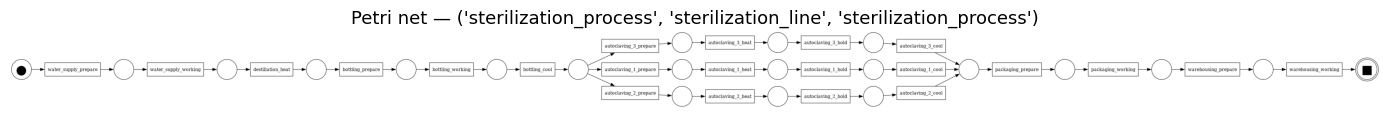

In [55]:
# Visualize Petri nets (real vs simulated placeholder)
import tempfile, matplotlib.image as mpimg
net, im, fm = entry['net'], entry['im'], entry['fm']
with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tf:
    tmp_path = tf.name
pm4py.save_vis_petri_net(net, im, fm, tmp_path, bgcolor='white')
img = mpimg.imread(tmp_path)
os.unlink(tmp_path)
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(img); ax.axis('off'); ax.set_title(f'Petri net — {first_key}', fontsize=13)
plt.tight_layout(); plt.show()

## 6 · ML Features Inspection (SimModeller Input)

In [56]:
# SimModeller will build a feature matrix from the event log + expanded.
# Let's see what that looks like before training.
modeller = SimModeller(
    model_types=ML_MODEL_TYPES,
    optimize_hyperparams=OPTIMIZE_HYPERPARAMS,
)

# Peek at the feature construction
# (call the internal feature builder without full fit if available)
print('SimModeller config:')
print(f'  model_types: {ML_MODEL_TYPES}')
print(f'  optimize_hyperparams: {OPTIMIZE_HYPERPARAMS}')
print(f'  event_log shape: {el_train.shape}')
if exp_train is not None:
    print(f'  expanded shape:   {exp_train.shape}')

# Show columns available as features
feature_candidates = [c for c in el_train.columns
                      if c not in ('timestamp_start', 'timestamp_end', 'case_id')]
print(f'\nEvent log feature candidates: {feature_candidates}')

SimModeller config:
  model_types: ['xgboost']
  optimize_hyperparams: False
  event_log shape: (5600, 10)
  expanded shape:   (400, 20)

Event log feature candidates: ['activity', 'higher_level_activity', 'station', 'object_type', 'object', 'object_attributes', 'duration_min']


## 7 · Train Simulation Models

In [57]:
print(f"Training SimModeller ({ML_MODEL_TYPES}) on {PROCESS_NAME} train set ...")
# SimModeller.train() takes (raw_df, stats_df) — both come from extract_process()
modeller.train(
    raw_df=raw_df,
    stats_df=stats_df,
)
print("SimModeller training complete.")


Training SimModeller (['xgboost']) on process_1 train set ...

[SimModeller] Model types      : ['xgboost']
[SimModeller] Optuna tuning    : False
[SimModeller] Internal val %   : 20%
[SimModeller] Feature columns  : ['attr_recipe', 'attr_volume_L', 'prev_activity_1', 'prev_duration_1', 'prev_activity_2', 'prev_duration_2']

  Key: ('autoclaving_1_cool', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Fit size: 108, Val size: 27, Total: 135
    Duration [ xgboost]  MAE=0.871  RMSE=1.881  R²=0.898
    ✓ Best duration model: xgboost  (val MAE=0.871)

  Key: ('autoclaving_1_heat', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Fit size: 108, Val size: 27, Total: 135
    Duration [ xgboost]  MAE=0.628  RMSE=1.602  R²=0.812
    ✓ Best duration model: xgboost  (val MAE=0.628)

  Key: ('autoclaving_1_hold', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Fit size: 108, Val size: 27, Total: 135
    Duration [ 

In [58]:
# Inspect per-activity models
# duration_models[key] = (model, feature_cols, model_type)
# metrics are in duration_val_metrics[key]

if modeller.duration_models:
    print(f"Duration models trained: {len(modeller.duration_models)}")
    for key, (mdl, feat_cols, mtype) in list(modeller.duration_models.items())[:6]:
        metrics = modeller.duration_val_metrics.get(key, {})
        print(f"  {key}")
        print(f"    model_type={mtype}  features={feat_cols}")
        if metrics:
            mae = metrics.get("mae")
            r2 = metrics.get("r2")

            if mae is not None and r2 is not None:
                print(f"    val_mae={mae:.4f}  val_r2={r2:.4f}")
            else:
                print(f"    val_mae={mae}  val_r2={r2}")

if modeller.transition_models:
    print(f"Transition models trained: {len(modeller.transition_models)}")
    for key, (mdl, le, feat_cols, mtype) in list(modeller.transition_models.items())[:6]:
        metrics = modeller.transition_val_metrics.get(key, {})
        print(f"  {key}")
        print(f"    model_type={mtype}  classes={list(le.classes_)[:5]}")
        if metrics:
            accuracy = metrics.get("accuracy")
            f1 = metrics.get("f1")

            if accuracy is not None and f1 is not None:
                print(f"    val_acc={accuracy:.4f}  val_f1={f1:.4f}")
            else:
                print(f"    val_acc={accuracy}  val_f1={f1}")

Duration models trained: 22
  ('autoclaving_1_cool', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    model_type=xgboost  features=['attr_recipe', 'attr_volume_L', 'prev_activity_1', 'prev_duration_1', 'prev_activity_2', 'prev_duration_2']
    val_mae=0.8715  val_r2=0.8980
  ('autoclaving_1_heat', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    model_type=xgboost  features=['attr_recipe', 'attr_volume_L', 'prev_activity_1', 'prev_duration_1', 'prev_activity_2', 'prev_duration_2']
    val_mae=0.6279  val_r2=0.8120
  ('autoclaving_1_hold', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    model_type=xgboost  features=['attr_recipe', 'attr_volume_L', 'prev_activity_1', 'prev_duration_1', 'prev_activity_2', 'prev_duration_2']
    val_mae=0.7737  val_r2=0.6106
  ('autoclaving_1_prepare', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    model_type=xgboost  features=['attr_recipe', 'att

## 8 · Run Simulation

In [59]:
n_cases = N_CASES_TO_SIMULATE or el_test["case_id"].nunique()
print(f"Running simulation: mode={SIMULATION_MODE}  cases={n_cases}")

# Limit production plan to n_cases
pp_test = pdata_test["production_plan"]
pp_sim  = pp_test.head(n_cases) if len(pp_test) >= n_cases else pp_test

simulator = ProcessSimulation(
    activity_stats_df=stats_df,
    production_plan=pp_sim,
    mode=SIMULATION_MODE,
    ml_models=modeller,
    process_models=process_models,
)
simulated_log = simulator.run()
print(f"Simulated log shape: {simulated_log.shape}")
display(simulated_log.head(5))


Running simulation: mode=petri_net_inductive  cases=100
[DEBUG __init__] mode=petri_net_inductive, process_models is None: False, process_models len: 1
Building config from 22 activities:
  Config: ('water_supply_prepare', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'water_supply_working': 1.0}
    Start: True
  Config: ('water_supply_working', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'destillation_heat': 1.0}
    Start: False
  Config: ('destillation_heat', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'bottling_prepare': 1.0}
    Start: False
  Config: ('bottling_prepare', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'bottling_working': 1.0}
    Start: False
  Config: ('bottling_working', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'bottling_cool': 1.0}
    

,case_id,activity,timestamp_start,timestamp_end,object,object_type,higher_level_activity,object_attributes
0,batch_401,water_supply_prepare,2024-01-19 05:00:00.000000,2024-01-19 05:00:06.000000,sterilization_process,sterilization_line,sterilization_process,"{'recipe': 'standard', 'volume_L': 360.0}"
1,batch_401,water_supply_working,2024-01-19 05:00:07.000000,2024-01-19 05:01:32.217270,sterilization_process,sterilization_line,sterilization_process,"{'recipe': 'standard', 'volume_L': 360.0}"
2,batch_401,destillation_heat,2024-01-19 05:01:33.217270,2024-01-19 05:01:55.711486,sterilization_process,sterilization_line,sterilization_process,"{'recipe': 'standard', 'volume_L': 360.0}"
3,batch_401,bottling_prepare,2024-01-19 05:01:56.711486,2024-01-19 05:02:02.711486,sterilization_process,sterilization_line,sterilization_process,"{'recipe': 'standard', 'volume_L': 360.0}"
4,batch_401,bottling_working,2024-01-19 05:02:03.711486,2024-01-19 05:02:46.082661,sterilization_process,sterilization_line,sterilization_process,"{'recipe': 'standard', 'volume_L': 360.0}"


In [60]:
# Quick sanity check: activity counts comparison
_comparison = pd.DataFrame({
    'real':      el_test['activity'].value_counts(),
    'simulated': simulated_log['activity'].value_counts() if 'activity' in simulated_log.columns else 0,
}).fillna(0)
display(_comparison)

,real,simulated
activity,,
autoclaving_1_cool,34,29
autoclaving_1_heat,34,29
autoclaving_1_hold,34,29
autoclaving_1_prepare,34,29
autoclaving_2_cool,33,39
autoclaving_2_heat,33,39
autoclaving_2_hold,33,39
autoclaving_2_prepare,33,39
autoclaving_3_cool,33,32


## 9 · Evaluate Simulation

In [61]:
eval_results = comprehensive_simulation_evaluation(
    simulated_df=simulated_log,
    real_df=el_test,
    process_models=process_models,
    verbose=True,
)

COMPREHENSIVE SIMULATION EVALUATION

1. BASIC PROCESS METRICS
Events — Real: 1400, Sim: 1400, Ratio: 1.000
Cases  — Real: 100,  Sim: 100,  Ratio: 1.000

2. ACTIVITY FREQUENCY ANALYSIS
JS Divergence (activities): 0.0255
Freq MAE: 0.0016

3. DURATION ANALYSIS


         Real  Simulated  Error
Mean    5.038      5.437  0.079
Median  1.410      1.997  0.417
Std     7.350      7.537  0.026
KS=0.1129  p=0.0000  |  act-dur-err=0.1292  |  JS-whole=0.2612  JS-activ=0.5430

4. CASE-LEVEL ANALYSIS
        Real  Simulated  Error
Mean    14.0       14.0    0.0
Median  14.0       14.0    0.0
Std      0.0        0.0    1.0

5. CONTROL-FLOW ANALYSIS (DFG)
Edges — Real: 23, Sim: 23, Common: 23
EdgeF1=1.0000  StartJaccard=1.0000  EndJaccard=1.0000

6. CLASSIC PM CONFORMANCE

7. OVERALL QUALITY SCORE
Overall error: 0.2744  (FAIR)


In [62]:
# Flatten results into a DataFrame for easy inspection
flat = {}
for section, metrics in eval_results.items():
    if isinstance(metrics, dict):
        for metric_name, value in metrics.items():
            flat[f'{section}_{metric_name}'] = value
    elif not isinstance(metrics, str):
        flat[section] = metrics

results_series = pd.Series(flat).sort_index()
display(results_series.to_frame('value'))

,value
activity_metrics_activity_coverage_ratio,1.000000e+00
activity_metrics_frequency_mae,1.558442e-03
activity_metrics_js_divergence,1.980420e-01
basic_metrics_case_count_error,0.000000e+00
basic_metrics_case_count_ratio,1.000000e+00
basic_metrics_event_count_error,0.000000e+00
basic_metrics_event_count_ratio,1.000000e+00
case_metrics_events_per_case_ks,0.000000e+00
case_metrics_events_per_case_pvalue,1.000000e+00
case_metrics_mean_events_per_case_error,0.000000e+00


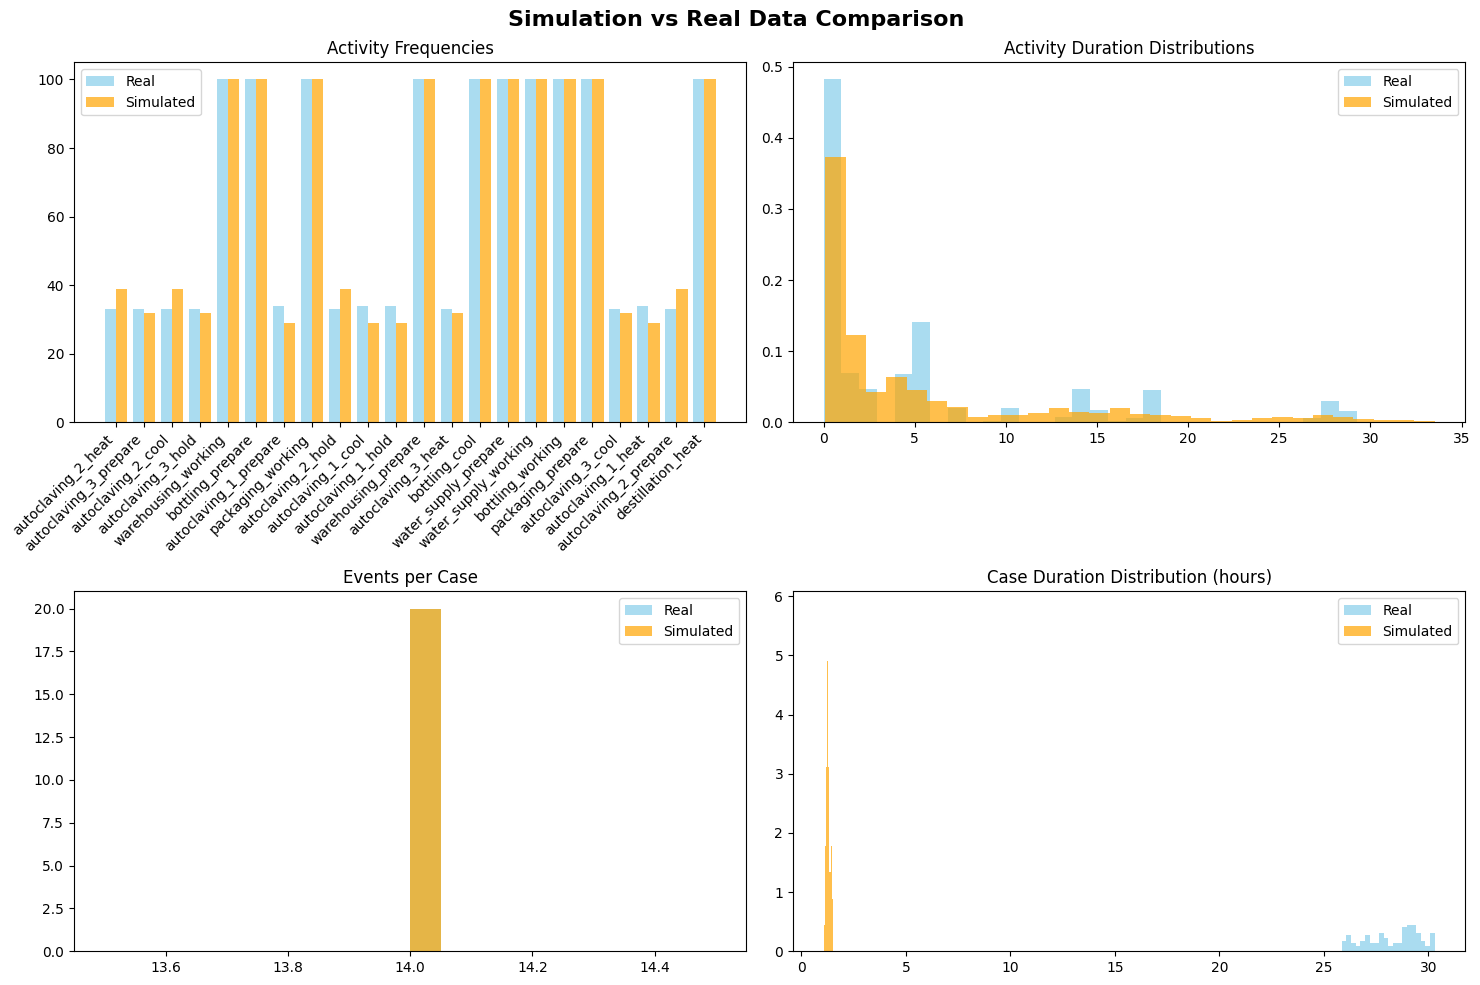

In [63]:
plot_simulation_comparison(simulated_log, el_test)

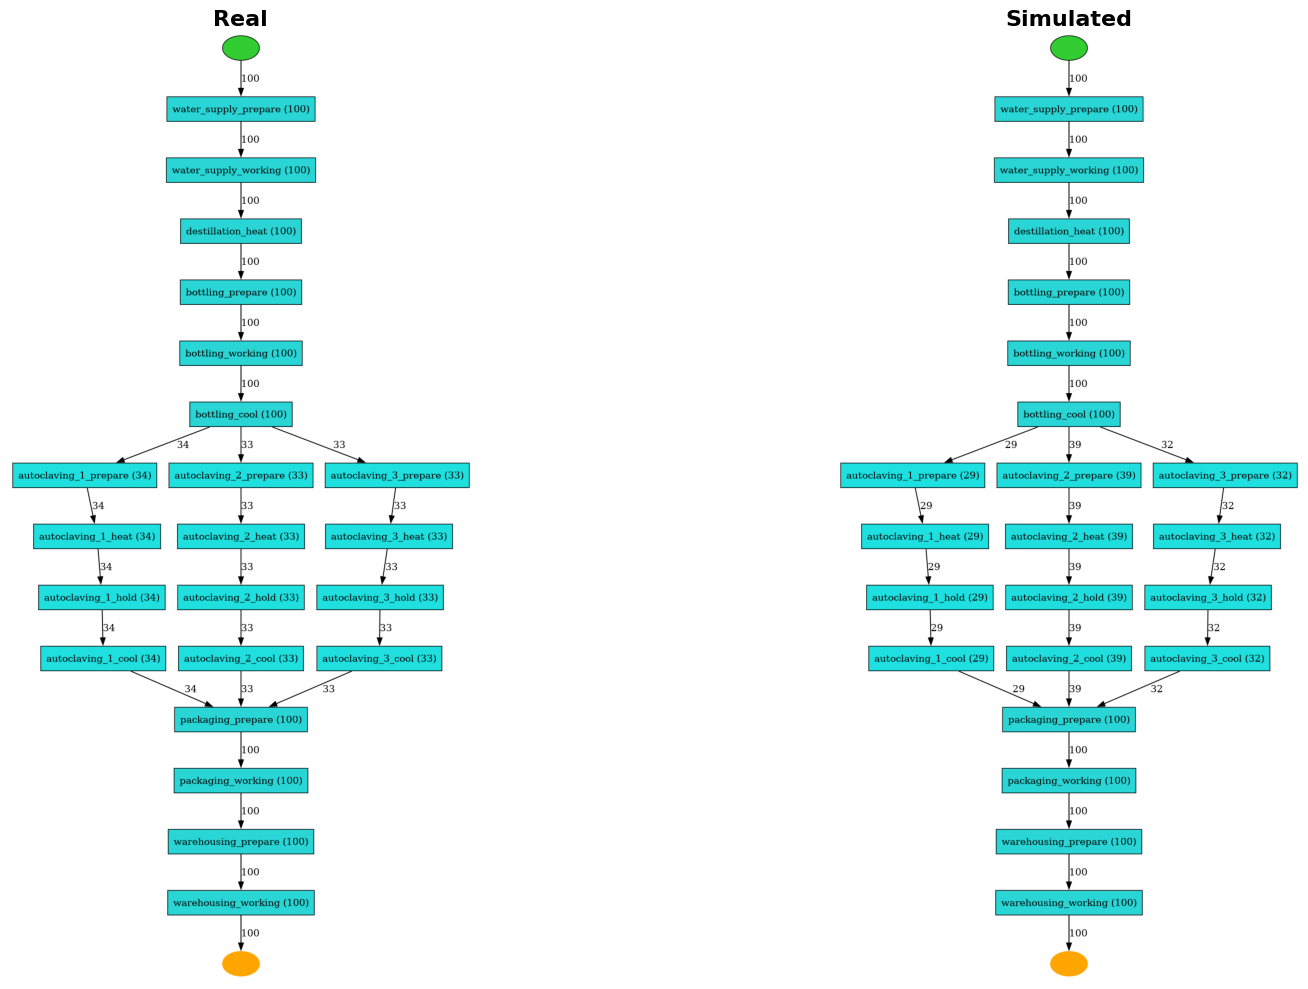

In [64]:
visualize_heuristic_nets(el_test, simulated_log)

## 10 · Compare Multiple Modes

Run several modes and produce a heatmap — same logic as the full pipeline but interactive.

In [65]:
# Edit this list to select which modes to compare
MODES_TO_RUN = [
    "statistical",
    "petri_net_heuristic",
    "petri_net_inductive",
]

all_eval_rows = []

for mode in MODES_TO_RUN:
    print(f"--- {mode} ---")
    try:
        pp_sim_mode = pdata_test["production_plan"].head(n_cases)
        sim = ProcessSimulation(
            activity_stats_df=stats_df,
            production_plan=pp_sim_mode,
            mode=mode,
            ml_models=modeller,
            process_models=process_models,
        )
        sim_log = sim.run()
        res = comprehensive_simulation_evaluation(sim_log, el_test, verbose=False)
        row = {"mode": mode}
        for sec, vals in res.items():
            if isinstance(vals, dict):
                for k, v in vals.items():
                    row[f"test_{sec}_{k}"] = v
            elif not isinstance(vals, str):
                row[f"test_{sec}"] = vals
        all_eval_rows.append(row)
        print(f"  overall_error={res.get('overall_error', '?')}  quality={res.get('quality_assessment', '?')}")
    except Exception as exc:
        print(f"  FAILED: {exc}")

evaluation_results_df = pd.DataFrame(all_eval_rows)
print(f"Collected {len(evaluation_results_df)} mode results.")


--- statistical ---
[DEBUG __init__] mode=statistical, process_models is None: False, process_models len: 1
Building config from 22 activities:
  Config: ('water_supply_prepare', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'water_supply_working': 1.0}
    Start: True
  Config: ('water_supply_working', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'destillation_heat': 1.0}
    Start: False
  Config: ('destillation_heat', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'bottling_prepare': 1.0}
    Start: False
  Config: ('bottling_prepare', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'bottling_working': 1.0}
    Start: False
  Config: ('bottling_working', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'bottling_cool': 1.0}
    Start: False
  Config: ('bottling_cool', 'st

Case batch_494: Found 1 unique object configurations:
  - sterilization_process (sterilization_line) with higher_level: sterilization_process

Case batch_494: Simulating sterilization_process (sterilization_line) process
  Looking for start activities for: sterilization_process (sterilization_line) with higher_level: sterilization_process
    Found start activity: water_supply_prepare
  Starting with activity: water_supply_prepare
    Processing activity 1: water_supply_prepare
    Looking for transitions from: water_supply_prepare
    Statistical transitions: {'water_supply_working': 1.0}
    Selected next activity: water_supply_working
    Processing activity 2: water_supply_working
    Looking for transitions from: water_supply_working
    Statistical transitions: {'destillation_heat': 1.0}
    Selected next activity: destillation_heat
    Processing activity 3: destillation_heat
    Looking for transitions from: destillation_heat
    Statistical transitions: {'bottling_prepare': 1.

In [66]:
n_cases = N_CASES_TO_SIMULATE or el_test["case_id"].nunique()
print(f"Running simulation: mode={SIMULATION_MODE}  cases={n_cases}")

# Limit production plan to n_cases
pp_test = pdata_test["production_plan"]
pp_sim  = pp_test.head(n_cases) if len(pp_test) >= n_cases else pp_test

simulator = ProcessSimulation(
    activity_stats_df=stats_df,
    production_plan=pp_sim,
    mode=SIMULATION_MODE,
    ml_models=modeller,
    process_models=process_models,
)
simulated_log = simulator.run()
print(f"Simulated log shape: {simulated_log.shape}")
display(simulated_log.head(5))


Running simulation: mode=petri_net_inductive  cases=100
[DEBUG __init__] mode=petri_net_inductive, process_models is None: False, process_models len: 1
Building config from 22 activities:
  Config: ('water_supply_prepare', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'water_supply_working': 1.0}
    Start: True
  Config: ('water_supply_working', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'destillation_heat': 1.0}
    Start: False
  Config: ('destillation_heat', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'bottling_prepare': 1.0}
    Start: False
  Config: ('bottling_prepare', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'bottling_working': 1.0}
    Start: False
  Config: ('bottling_working', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'bottling_cool': 1.0}
    

,case_id,activity,timestamp_start,timestamp_end,object,object_type,higher_level_activity,object_attributes
0,batch_401,water_supply_prepare,2024-01-19 05:00:00.000000,2024-01-19 05:00:06.000000,sterilization_process,sterilization_line,sterilization_process,"{'recipe': 'standard', 'volume_L': 360.0}"
1,batch_401,water_supply_working,2024-01-19 05:00:07.000000,2024-01-19 05:01:32.217270,sterilization_process,sterilization_line,sterilization_process,"{'recipe': 'standard', 'volume_L': 360.0}"
2,batch_401,destillation_heat,2024-01-19 05:01:33.217270,2024-01-19 05:01:55.711486,sterilization_process,sterilization_line,sterilization_process,"{'recipe': 'standard', 'volume_L': 360.0}"
3,batch_401,bottling_prepare,2024-01-19 05:01:56.711486,2024-01-19 05:02:02.711486,sterilization_process,sterilization_line,sterilization_process,"{'recipe': 'standard', 'volume_L': 360.0}"
4,batch_401,bottling_working,2024-01-19 05:02:03.711486,2024-01-19 05:02:46.082661,sterilization_process,sterilization_line,sterilization_process,"{'recipe': 'standard', 'volume_L': 360.0}"


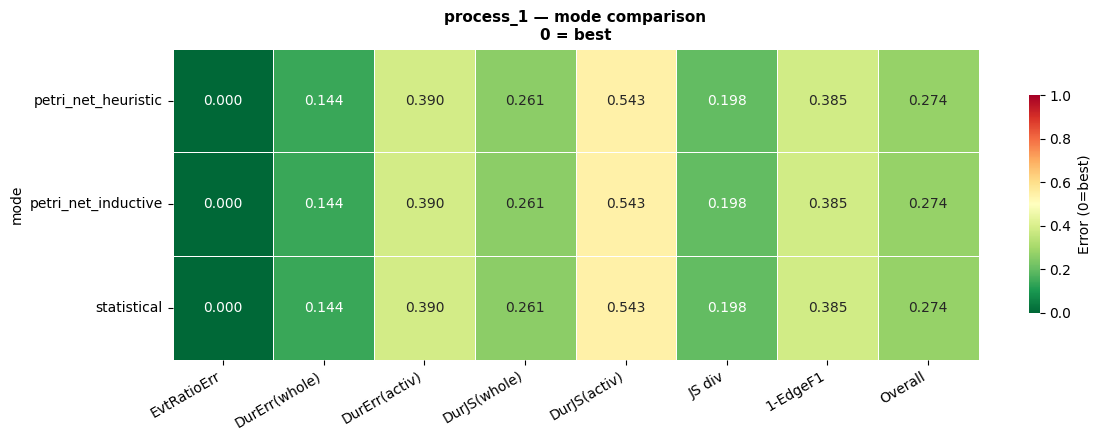


process_1 — mode comparison
------------------------------------------------------------
                     EvtRatioErr  DurErr(whole)  DurErr(activ)  DurJS(whole)  DurJS(activ)  JS div  1-EdgeF1  Overall
mode                                                                                                                 
petri_net_heuristic          0.0         0.1443         0.3897        0.2612         0.543   0.198    0.3846   0.2744
petri_net_inductive          0.0         0.1443         0.3897        0.2612         0.543   0.198    0.3846   0.2744
statistical                  0.0         0.1443         0.3897        0.2612         0.543   0.198    0.3846   0.2744


In [67]:
try:
    evaluation_results_df
except NameError:
    print("Run the multi-mode loop cell above first.")
else:
    if not evaluation_results_df.empty:
        _plot_short_heatmap(evaluation_results_df,
                            f"{PROCESS_NAME} — mode comparison",
                            split="test")
    else:
        print("No results collected — check the loop cell above.")


## 11 · Energy Profile Extraction

Inspect the input data and train `EnergyProfileExtractor`.
Set `ENERGY_SENSOR_COL` in the Config cell above to activate.

In [68]:
if ENERGY_SENSOR_COL is None:
    print('ENERGY_SENSOR_COL is None — skipping energy section.')
    print('Set it to a column name in the expanded DataFrame (see Section 4).')
else:
    print(f'Energy sensor: {ENERGY_SENSOR_COL}')

ENERGY_SENSOR_COL is None — skipping energy section.
Set it to a column name in the expanded DataFrame (see Section 4).


In [69]:
# Show what EnergyProfileExtractor receives as input
if ENERGY_SENSOR_COL and exp_train is not None:
    _required_cols = ["case_id", "activity", "start_end", "datetime_energy", ENERGY_SENSOR_COL]
    _avail = [c for c in _required_cols if c in exp_train.columns]
    print(f"Columns available: {_avail}")
    print(f"Columns needed but missing: {set(_required_cols) - set(_avail)}")
    display(exp_train[_avail].head(10))


In [70]:
if ENERGY_SENSOR_COL and exp_train is not None and ENERGY_SENSOR_COL in exp_train.columns:
    extractor = EnergyProfileExtractor(
        value_column=ENERGY_SENSOR_COL,
        case_id_column='case_id',
        activity_column='activity',
        start_end_column='start_end',
        timestamp_column='datetime_energy',
        verbose=True,
    )
    results_df = extractor.fit(exp_train)
    print('\nModel performance:')
    display(results_df)

In [71]:
if ENERGY_SENSOR_COL and exp_train is not None and ENERGY_SENSOR_COL in exp_train.columns:
    # Predict curves for each activity and compare to extracted real curves
    activities = exp_train['activity'].dropna().unique()
    n_a = len(activities)
    fig, axes = plt.subplots(1, n_a, figsize=(5 * n_a, 3))
    if n_a == 1: axes = [axes]

    for ax, act in zip(axes, activities):
        # Plot a sample of real curves
        real_curves = [c['values'] for c in extractor.curves_ if c['activity'] == act]
        for rc in real_curves[:5]:
            ax.plot(np.linspace(0, 1, len(rc)), rc, color='skyblue', alpha=0.4, lw=0.8)
        # Plot predicted curve (median output_length)
        if real_curves:
            median_len = int(np.median([len(c) for c in real_curves]))
            pred = extractor.predict_curve(activity=act, output_length=median_len)
            ax.plot(np.linspace(0, 1, len(pred)), pred, color='red', lw=1.5, label='predicted')
        ax.set_title(act, fontsize=9); ax.legend(fontsize=7)

    plt.suptitle(f'{ENERGY_SENSOR_COL} — real curves (blue) vs predicted (red)', fontsize=11)
    plt.tight_layout(); plt.show()

## 12 · Debug Helpers

Utility cells for drilling into specific cases or activities.

In [72]:
# Drill into a specific case: real vs simulated trace
CASE_TO_INSPECT = el_test["case_id"].iloc[0]  # change this

real_case = el_test[el_test["case_id"] == CASE_TO_INSPECT].sort_values("timestamp_start").copy()
real_case["duration_min"] = (real_case["timestamp_end"] - real_case["timestamp_start"]).dt.total_seconds() / 60

sim_case = (
    simulated_log[simulated_log["case_id"] == CASE_TO_INSPECT].sort_values("timestamp_start")
    if "case_id" in simulated_log.columns else pd.DataFrame()
)

print(f"=== Case {CASE_TO_INSPECT} ===")
print(f"Real trace ({len(real_case)} events):")
display(real_case[["activity", "timestamp_start", "timestamp_end", "duration_min"]].head(20))

if not sim_case.empty:
    print(f"Simulated case ({len(sim_case)} events):")
    display(sim_case[["activity", "timestamp_start", "timestamp_end"]].head(20))
else:
    print(f"No simulated case found for case_id={CASE_TO_INSPECT!r}")
    print("Available simulated case_ids:", simulated_log["case_id"].unique()[:10] if "case_id" in simulated_log.columns else "none")


=== Case batch_401 ===
Real trace (14 events):


,activity,timestamp_start,timestamp_end,duration_min
4950,water_supply_prepare,2024-01-19 04:00:00.000000,2024-01-19 04:00:04.319561,0.071993
4951,water_supply_working,2024-01-19 04:00:05.319561,2024-01-19 04:00:57.667853,0.872472
4952,destillation_heat,2024-01-19 04:00:58.667853,2024-01-19 04:01:25.128839,0.441016
4953,bottling_prepare,2024-01-19 04:01:26.128839,2024-01-19 04:01:30.448400,0.071993
4954,bottling_working,2024-01-19 04:01:31.448400,2024-01-19 04:01:59.888544,0.474002
4956,bottling_cool,2024-01-19 04:02:00.888544,2024-01-19 04:02:05.208105,0.071993
6181,autoclaving_3_prepare,2024-01-20 04:31:50.621848,2024-01-20 04:33:47.149179,1.942122
6183,autoclaving_3_heat,2024-01-20 04:33:48.149179,2024-01-20 04:52:00.389551,18.204006
6198,autoclaving_3_hold,2024-01-20 04:52:01.389551,2024-01-20 05:06:21.910284,14.342012
6205,autoclaving_3_cool,2024-01-20 05:06:22.910284,2024-01-20 05:34:25.538772,28.043808


Simulated case (14 events):


,activity,timestamp_start,timestamp_end
0,water_supply_prepare,2024-01-19 05:00:00.000000,2024-01-19 05:00:06.000000
1,water_supply_working,2024-01-19 05:00:07.000000,2024-01-19 05:01:32.217270
2,destillation_heat,2024-01-19 05:01:33.217270,2024-01-19 05:01:55.711486
3,bottling_prepare,2024-01-19 05:01:56.711486,2024-01-19 05:02:02.711486
4,bottling_working,2024-01-19 05:02:03.711486,2024-01-19 05:02:46.082661
5,bottling_cool,2024-01-19 05:02:47.082661,2024-01-19 05:02:53.082661
6,autoclaving_3_prepare,2024-01-19 05:02:54.082661,2024-01-19 05:04:52.590342
7,autoclaving_3_heat,2024-01-19 05:04:53.590342,2024-01-19 05:19:49.117844
16,autoclaving_3_hold,2024-01-19 05:19:50.117844,2024-01-19 05:33:03.182160
25,autoclaving_3_cool,2024-01-19 05:33:04.182160,2024-01-19 05:57:24.079745


Activity: water_supply_prepare  |  n=400
Best distribution: weibull_min  params=(3.206664116615306, 0.0, 0.10869980704219756)


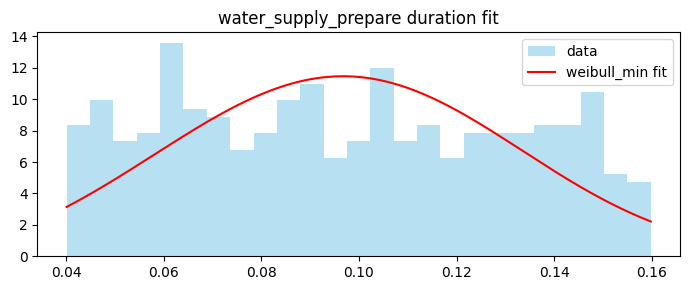

In [73]:
# Drill into a specific activity's duration fit
ACTIVITY_TO_INSPECT = el_train['activity'].iloc[0]  # change this

act_data = el_train[el_train['activity'] == ACTIVITY_TO_INSPECT]
if 'duration_min' not in act_data.columns:
    act_data = act_data.copy()
    act_data['duration_min'] = (act_data['timestamp_end'] - act_data['timestamp_start']).dt.total_seconds() / 60

durations = act_data['duration_min'].dropna().values
dist_name, dist_params = fit_best_distribution(durations)

print(f'Activity: {ACTIVITY_TO_INSPECT}  |  n={len(durations)}')
print(f'Best distribution: {dist_name}  params={dist_params}')

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(durations, bins=25, density=True, alpha=0.6, color='skyblue', label='data')
x = np.linspace(durations.min(), durations.max(), 200)
from scipy import stats as scipy_stats
dist_obj = getattr(scipy_stats, dist_name)
ax.plot(x, dist_obj.pdf(x, *dist_params), 'r-', lw=1.5, label=f'{dist_name} fit')
ax.set_title(f'{ACTIVITY_TO_INSPECT} duration fit'); ax.legend()
plt.tight_layout(); plt.show()

In [74]:
# Show transition probabilities from the Petri net token replay
for key, entry in process_models.items():
    if 'transition_probs' in entry:
        print(f'Transition probs — {key}:')
        for act, probs in list(entry['transition_probs'].items())[:5]:
            print(f'  {act}: {dict(sorted(probs.items(), key=lambda x: -x[1])[:5])}')
    elif 'next_activity_probs' in entry:
        print(f'Next-activity probs — {key}:')
        display(pd.DataFrame(entry['next_activity_probs']))